# Introduction

This document is created to get you familiar with my horrible codes from this pedestrian crowd project. You can tell how horrible and unorganized I was based on the number of random notebooks I've prototyped throughout the last 1-2 year or so. But ignore those notebooks for now, as hopefully this notebook alone (with some debugging) should be able to get you the necessary components of a complete pipeline that will: 
1. Load the spatio-temporal crowd flow graphs
    This graph dataset was created by integrating spatial and temporal information in the previous paper V. W. H. Wong and K. H. Law, Fusion of CCTV Video and Spatial Information for Automated Crowd Congestion Monitoring in Public Urban Spaces. Algorithms, Mar 2023, 16(3):154. https://doi.org/10.3390/a16030154. As opposed to this previous paper which relies only on one single-camera dataset to do the crowd flow estimation, there are two more self-collected data sources now integrated with multiple cameras. 
2. Prediction
3. Visualization of hostpots 

Proposed title of a publication resulting from this line of work could be something along the lines of: 
"ST-DIF: A spatio-temporal data integration framework to estimate pedestrian crowd flow from multi-camera surveillance in built environments"


# 0. Setup environment

## 0.1 set up a conda environment following the README instructions

## 0.2. Import packages

In [1]:
import os
import sys
import torch

from tqdm.notebook import tqdm # might have to install this if you don't have it

# for relative imports
os.chdir('..') 
print(os.getcwd()) # should print /your_local_dir/crowd-framework

from st_dif.data_utils import get_pyg_temporal_dataset, get_loaders
from st_dif.models import DenseGCNGRU, GCNGRU, GRU_only
from st_dif import train, evaluate, save_or_update_checkpoint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # should say 'cpu' if you're using mac.
print(device)

/Users/vivianwong/Documents/Research Codes/crowd-framework
cpu


In [2]:
class Args:
    def __init__(self):
        self.DATASET = 'Stadium'
        self.forecasting_horizon = 20

args = Args()

# 0.3 Try running the two demo notebooks from Campus Crowd subset before moving on

# 1. Crowd Flow Dataset
We have 2 subsets of data in this framework: GCS (a public one), Campus Crowd ( collected at Stanford). Both were videos but post-processed with CNN to detect and track pedestrian info. 

1. The first subset, Campus Crowd, is the original pedestrian data I collected back at Stanford was videos. Due to IRB regulations they are anonymised and are stored in CSV. They are available to public use at https://github.com/vivian-wong/Campus-Crowd. I recently cleanedup the campus crowd repo, so the get_pyg_temporal_dataset function is much more well-developed. Most files in this repo are from the campus crowd repo, but i reorganized some files for clarity. 

2. The second subset, Grand Central Station (GCS), is a public dataset. GCS will be loaded using the class GCSDatasetLoaderStatic. It is very ugly right now and I hope to have it integrated into this repo just like the campus crowd data. 

## 1.1. Getting familiar with the more well-developed campus crowd dataset loader 

You've seen in the demo_dataset notebook how we can call get_pyg_temporal_dataset

In [3]:
dataset, cmgraph = get_pyg_temporal_dataset(args.DATASET, args.forecasting_horizon)

Dataset type:   <torch_geometric_temporal.signal.static_graph_temporal_signal.StaticGraphTemporalSignal object at 0x106e13d60>
Number of samples / sequences:  2356
Data(x=[6, 2, 20], edge_index=[2, 10], edge_attr=[10], y=[6, 20])


get_pyg_temporal_dataset currently ONLY SUPPORTS the campus crowd subset. The function is pasted below for your reference (from data_utils.py): 
```python
import configparser
from st_dif.cmgraph import CMGraph

config_file_paths = {
    'SEQ':    './crowd-framework/data/campus-crowd-processed/SEQ.cfg', 
    'Stadium':'./crowd-framework/data/campus-crowd-processed/Stadium_2023.cfg'
}

def get_pyg_temporal_dataset(DATASET, forecasting_horizon): 
    '''
    Parameters:
        raise ValueError(f"DATASET must be one of: {', '.join(config_file_paths.keys())}")
    forecasting_horizon (int): The number of timesteps for forecasting.

    Returns:
    torch_geometric_temporal.signal.StaticGraphTemporalSignal: 
        A static graph temporal signal object containing the dataset.
    '''

    if DATASET not in config_file_paths.keys():
        raise ValueError("DATASET must be one of: ", config_file_paths.keys())
    
    configs_dict = get_configs_dict(config_file_paths[DATASET])
    flow_df = pd.read_csv(configs_dict['csv-path']['flow_df_path'])
    ... # irrelevant lines ommitted for conciseness
``` 
Essentially, as long as there is a config file supplied in the config_file_paths directory, the get_pyg_temporal_dataset function will parse the config file and read the crowd flow data csv in the config file. There's a lot of irrelevant information in the config file on original video data. But the most important part is below (for Stadium scenario, as an example): 
```python
[csv-path]
flow_df_path = ./campuscrowd/data_processed/flow_df_stadium_2023_1fps.csv

[CMGraph]
adjacency_mat = 0,1,0,0,0,0
                1,0,1,0,0,0
                0,1,0,1,0,0
                0,0,1,0,1,0
                0,0,0,1,0,1
                0,0,0,0,1,0
                
```
FYI, the csv contains the crowd flow data and it looks like this

In [4]:
cmgraph.flow_df

,timestamp,speed,num_people,cam_name,PAR_id,frame_number,raw_frame_number
0,0.0,NaN,1.0,Tunnel A,1,0.0,0.0
1,1.0,11.823683,2.0,Tunnel A,1,1.0,29.0
2,2.0,340.117319,2.0,Tunnel A,1,2.0,58.0
3,3.0,210.030362,1.0,Tunnel A,1,3.0,87.0
4,4.0,381.040588,1.0,Tunnel A,1,4.0,116.0
...,...,...,...,...,...,...,...
14770,2471.0,119.711735,8.0,Tunnel F,6,2471.0,71659.0
14771,2472.0,73.658169,6.0,Tunnel F,6,2472.0,71688.0
14772,2473.0,79.251304,5.0,Tunnel F,6,2473.0,71717.0
14773,2474.0,106.736505,4.0,Tunnel F,6,2474.0,71746.0


However, right now, data from the GCS scenario cannot be loaded with the above code. The reason is that it is a public dataset that comes with the 'data/gcs/Annotation/' folder, which is a completely different format compared to the above one from campus crowd. So, I created a dataset class just for GCS as a temporary solution.

## 1.2. GCS dataset class

In [17]:
import pandas as pd
import numpy as np
from scipy import interpolate
import torch
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data, Dataset, DataLoader

# parse original annotations to see which agents have been split due to noncontinuous timestamps
# note some trajs too short removed
# parse original annotations to see which agents have been split due to noncontinuous frame_numbers
# note some trajs too short removed
def image_to_world(p, Homog):
    '''
    to project original image coordinates to world coordinates with the given homography matrix. 
    p: a np array of [x1, y1; x2, y2; ... ] 
    '''
    # from Opentraj repo
    pp = np.stack((p[:, 0], p[:, 1], np.ones(len(p))), axis=1) # append a rightmost column of 1s
    PP = np.matmul(Homog, pp.T).T # [world x, world y, 1] (3 x 3)
    P_normal = PP / np.repeat(PP[:, 2].reshape((-1, 1)), 3, axis=1)  # normalize since the third column is not exactly 1??
    return P_normal[:, :2]*0.8 # not sure why *0.8 but that's in the code. 

def parse_gcs(path):
    # modified from https://github.com/crowdbotp/OpenTraj/blob/master/opentraj/toolkit/loaders/loader_gcs.py
    HOMOG = [[4.97412897e-02, -4.24730883e-02, 7.25543911e+01],
             [1.45017874e-01, -3.35678711e-03, 7.97920970e+00],
             [1.36068797e-03, -4.98339188e-05, 1.00000000e+00]]
    FPS = 25
    FRAME_STEPSIZE = 20
    
    raw_data_list = []  # the data to be converted into Pandas DataFrame
    file_list = sorted(os.listdir(path))
    
    for annot_file in file_list:
        annot_file_full_path = os.path.join(path, annot_file)
        with open(annot_file_full_path, 'r') as f:
            annot_contents = f.read().split()

        agent_id = int(annot_file.replace('.txt', ''))

        for i in range(len(annot_contents) // 3):
            py = float(annot_contents[3 * i])
            px = float(annot_contents[3 * i + 1])
            frame_id = int(annot_contents[3 * i + 2])
            raw_data_list.append([frame_id, agent_id, px, py])
    
    # fill frame_id, agent_id, x, y, timestamp
    df_columns = ["frame_id", "agent_id", "pos_x", "pos_y"]
    raw_data_frame = pd.DataFrame(np.stack(raw_data_list), columns=df_columns)
    raw_df_groupby = raw_data_frame.groupby("agent_id")
    trajs = [g for _, g in raw_df_groupby]
    temp_df = pd.DataFrame(columns=["frame_id", "agent_id", "pos_x", "pos_y"])

    # interpolate x,y from F=frame number, so that we can fill in xy for non-continuous timestamps
    for ii, tr in enumerate(trajs):
        if len(tr) < 2: continue
        interp_F = np.arange(tr["frame_id"].iloc[0], tr["frame_id"].iloc[-1], FRAME_STEPSIZE).astype(int)
        interp_func = interpolate.interp1d(tr["frame_id"], tr["pos_x"], kind='linear')
        interp_X_ = interp_func(interp_F)
        interp_func = interpolate.interp1d(tr["frame_id"], tr["pos_y"], kind='linear')
        interp_Y_ = interp_func(interp_F)
        agent_id = int(tr["agent_id"].iloc[0])
        temp_df = pd.concat([temp_df, pd.DataFrame({"frame_id": interp_F,
                                                       "agent_id": agent_id,
                                                       "pos_x": interp_X_,
                                                       "pos_y": interp_Y_})])
    raw_data_frame = temp_df.reset_index()
    
    # world coordinate
    raw_data_frame[["img_x","img_y"]] = raw_data_frame[["pos_x","pos_y"]] # store original image coordinates 
    world_coords = image_to_world(raw_data_frame[["pos_x", "pos_y"]].to_numpy(), HOMOG)
    raw_data_frame[["pos_x", "pos_y"]] = pd.DataFrame(world_coords)
    raw_data_frame["timestamp"] = raw_data_frame["frame_id"] / FPS
    
    raw_df_groupby = raw_data_frame.groupby("agent_id")
    
    # remove the trajectories shorter than 2 frames
    single_length_inds = raw_df_groupby.head(1).index[raw_df_groupby.size() < 2]
    raw_data_frame = raw_data_frame.drop(single_length_inds)
    raw_df_groupby = raw_data_frame.groupby("agent_id")
        
    # fill velocities
    dt = raw_df_groupby["timestamp"].diff()

    if (dt > (FRAME_STEPSIZE/FPS+0.1)).sum(): # 0.1 tolerance
        print('Warning! too big dt')

    raw_data_frame["vel_x"] = (raw_df_groupby["pos_x"].diff() / dt).astype(float)
    raw_data_frame["vel_y"] = (raw_df_groupby["pos_y"].diff() / dt).astype(float)
    nan_inds = np.array(np.nonzero(dt.isnull().to_numpy())).reshape(-1)
    raw_data_frame["vel_x"].iloc[nan_inds] = raw_data_frame["vel_x"].iloc[nan_inds + 1].to_numpy()
    raw_data_frame["vel_y"].iloc[nan_inds] = raw_data_frame["vel_y"].iloc[nan_inds + 1].to_numpy()
    
    raw_df_groupby = raw_data_frame.groupby("agent_id")
    
    trajs = [g for _, g in raw_df_groupby]
    return trajs

class GCSDatasetLoaderStatic(): 
    '''
    Create a static graph temporal signal of people at GCS
    - nodes: each node is a floor plan-based zone / room. 
    - node feature = avg speed, time. 
    - edges: unweighted. 1 = two connected zones (include diagonal). 
    '''
    def __init__(self, 
                 trajs,
                 ZONE_LIST):
        self.trajs = trajs
        self.ZONE_LIST = ZONE_LIST
        self._read_data()
        
    def _read_data(self): 
        delta_t = self.trajs[0]['timestamp'].iloc[1]-self.trajs[0]['timestamp'].iloc[0]
#         assert delta_t == 0.8
        all_trajs = pd.concat(self.trajs)
        all_trajs['speed'] = np.sqrt(all_trajs['vel_x']**2 + all_trajs['vel_y']**2)
        self.all_trajs = all_trajs 
        
        num_nodes = len(self.ZONE_LIST)
        A = np.ones((num_nodes,num_nodes))
        A -= np.eye(num_nodes)
        A[0:2,4:] = np.zeros_like(A[0:1,4:])
        A[2:4,6:] = np.zeros_like(A[2:4,6:])
        A[4:6,8]  = np.zeros_like(A[4:6,8])
        A = np.triu(A)
        A = A + A.T - np.diag(np.diag(A))
        
        # group by zones, each having a time vs speed df.
        zone_dfs = []
        common_time = [0, 1e6]
        for i in range(num_nodes): 
            x1, y1, x2, y2 = self.ZONE_LIST[i]
            tr = self.all_trajs[
                 (self.all_trajs['pos_x'] > x1) & 
                 (self.all_trajs['pos_x'] < x2) & 
                 (self.all_trajs['pos_y'] > y1) & 
                 (self.all_trajs['pos_y'] < y2)
                ]
            tr = tr.sort_values(by=['timestamp'])
#             # resample mean over 1 sec.
#             tr['time'] = pd.to_datetime(tr["timestamp"], unit='s')
#             tr.set_index('time').resample('1S')['vel_x'].mean().reset_index()
#             delta_t = 1
            
            temp_df = pd.DataFrame(columns=["timestamp", "speed", "num_people"])
            groupby = tr.groupby("timestamp", as_index=False)
            for _,g in groupby: 
                mean_speed = g['speed'].mean()
                num_people = g['agent_id'].nunique()
                timestamp = g['timestamp'].min()
                temp_df = pd.concat([temp_df, pd.DataFrame({"timestamp": [timestamp],
                                                       "speed": [mean_speed],
                                                       "num_people": [num_people]
                                                      })])
            tr = temp_df
            interp_t = np.arange(tr["timestamp"].iloc[0], tr["timestamp"].iloc[-1], delta_t)
            interp_func = interpolate.interp1d(tr["timestamp"], tr["speed"], kind='linear')
            interp_X_ = interp_func(interp_t)
            interp_func = interpolate.interp1d(tr["timestamp"], tr["num_people"], kind='linear')
            interp_Y_ = interp_func(interp_t)
            zone_dfs.append(pd.DataFrame({"timestamp": interp_t,
                                          "speed": interp_X_,
                                          "num_people": interp_Y_}))
            common_time[0] = max(common_time[0], interp_t.min())
            common_time[1] = min(common_time[1], interp_t.max())
        
        zone_dfs_ = zone_dfs.copy()
        # crop out beginning and end with incomplete data
        for i, df in enumerate(zone_dfs):
            df = df.round({'timestamp':1})
            temp_df = df[(common_time[0] <= df['timestamp']) & 
                         (df['timestamp'] <= common_time[1])].copy()
            temp_df['cropped_time'] = (temp_df['timestamp'] - common_time[0])/(common_time[1]- common_time[0])
            zone_dfs_[i] = temp_df[['num_people','cropped_time']].to_numpy().transpose([1,0])
            zone_dfs[i] = temp_df[['num_people','cropped_time','timestamp','speed']] # only used to store in self.zone_dfs for outside access.
        X = np.stack(zone_dfs_)
        X = X.astype(np.float32)
        
        # Normalise as in DCRNN paper (via Z-Score Method)
        means = np.mean(X, axis=(0, 2))
        X = X - means.reshape(1, -1, 1)
        stds = np.std(X, axis=(0, 2))
        X = X / stds.reshape(1, -1, 1)

        self.A = torch.from_numpy(A)
        self.X = torch.from_numpy(X)
        
        # convert zone_dfs from list to dataframe with column PAR_id
        self.zone_dfs = []
        for i, df in enumerate(zone_dfs):
            df['PAR_id'] = i
            self.zone_dfs.append(df)

        self.zone_dfs = pd.concat(self.zone_dfs, ignore_index=True)

    def _get_edges_and_weights(self):
        edge_indices, values = dense_to_sparse(self.A)
        edge_indices = edge_indices.numpy()
        values = values.numpy()
        self.edges = edge_indices
        self.edge_weights = values


    def _generate_task(self, num_timesteps_in, num_timesteps_out):
        """Uses the node features of the graph and generates a feature/target
        relationship of the shape
        (num_nodes, num_node_features, num_timesteps_in) -> (num_nodes, num_timesteps_out)
        predicting the average traffic speed using num_timesteps_in to predict the
        traffic conditions in the next num_timesteps_out

        Args:
            num_timesteps_in (int): number of timesteps the sequence model sees
            num_timesteps_out (int): number of timesteps the sequence model has to predict
        """
        indices = [
            (i, i + (num_timesteps_in + num_timesteps_out))
            for i in range(self.X.shape[2] - (num_timesteps_in + num_timesteps_out) + 1)
        ]

        # Generate observations
        features, target = [], []
        for i, j in indices:
            features.append((self.X[:, :, i : i + num_timesteps_in]).numpy())
            target.append((self.X[:, 0, i + num_timesteps_in : j]).numpy())

        self.features = features
        self.targets = target
        
    def get_dataset(self, 
                    num_timesteps_in = 10, 
                    num_timesteps_out= 10): 
        '''10 step * 0.8 sec/step = 8 sec. '''
        self._get_edges_and_weights()
        self._generate_task(num_timesteps_in, num_timesteps_out)
        dataset = StaticGraphTemporalSignal(
            self.edges, self.edge_weights, self.features, self.targets
        )
        return dataset

With the above two gigantic chunks of code, we can now get a GCS dataset object 

In [ ]:
# might take a while to run. For my personal laptop it takes about 85 seconds.
data_dir = "./data/gcs"
trajs= parse_gcs(os.path.join(data_dir,"Annotation"))
PAR_LIST =[
    (0, 0, 28, 14),
    (28, 0, 55, 14),
    (0, 14, 28, 24),
    (28, 14, 55, 24),
    (0, 24, 28, 35),
    (28, 24, 55, 35),
    (0, 35, 28, 45),
    (28, 35, 55, 45),
    (0, 45, 55, 55)
]
dataset = GCSDatasetLoaderStatic(
    trajs=trajs,
    ZONE_LIST = PAR_LIST)

dataset.zone_dfs

,num_people,cropped_time,timestamp,speed,PAR_id
0,1.0,0.000000,7.2,1.191813,0
1,1.0,0.000192,8.0,1.191813,0
2,1.0,0.000384,8.8,1.876111,0
3,1.0,0.000576,9.6,1.413016,0
4,1.0,0.000767,10.4,1.413016,0
...,...,...,...,...,...
46903,4.0,0.999041,4172.8,0.000963,8
46904,4.0,0.999233,4173.6,0.000963,8
46905,4.0,0.999424,4174.4,0.000963,8
46906,4.0,0.999616,4175.2,0.000963,8


<Axes: xlabel='timestamp'>

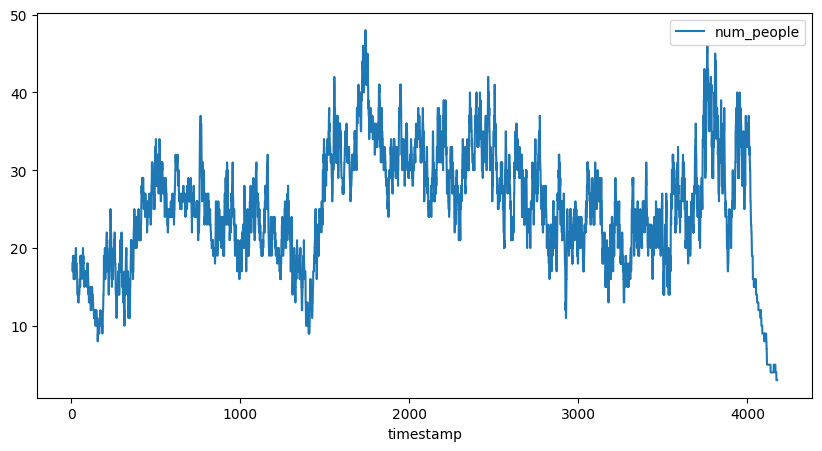

In [23]:
dataset.zone_dfs.query('PAR_id==5').plot(x='timestamp', y='num_people', figsize=(10,5))

# 2. Tasks Remaining (in the order of priority)

## 2.1. Merge data from Grand Central Station, so that it's all one package that people can easily experiment with 



You see how chunky GCS is compared to campus crowd... This will be very confusing when we need to publish our code because it is so inconsistent with the other data subset... So I'd like to ask for your help to convert GCS to the same format as the campus crowd subset. It should (1) be in a new directory called crowd-framework/data/gcs/gcs-processed. (2) have a new config file that looks something like this
```python
[csv-path]
flow_df_path = ./crowd-framework/data/gcs/gcs-processed/flow_df_gcs.csv

[CMGraph]
adjacency_mat = [type in dataset.A here]
```
(3) have a flow_df_gcs.csv file that is something like dataset.zone_dfs converted to a csv file. 
(4) be modified so that it can also be wrapped under the class in CMGraph.py - you may see that they already have very similar things, the only thing is that the _read_data() function in the GCS loader is super tedious. In the end GCS should be compatible with the functions and classes in data_utils.py so that dataset, cmgraph = get_pyg_temporal_dataset('GCS', args.forecasting_horizon) would give a dataset object and a cmgraph object just like you would get with 'Stadium' and 'SEQ'. 

With these steps completed, we would have a very clean and consistent dataset benchmark for other people to use for the task of crowd flow forecasting. To test it, we should be able to run demo_forecast_crowd_flow by changing the Args class to dataset being 'GCS'. 

Don't for get to commit your changes once everything runs!

## 2.2. Convert to a simple python package that's pip-installable and open source on github.
Now this is really out of my expertise... By this point we should have all the code ready for people to reproduce any experiment we run for our paper on crowd flow forecasting, but how do we turn it into a python library that people can just call easily by pip installing? My guess is to look up how to do this github suggested workflow...: 

![alt text](image.png)

## 2.3. Add visualization tools
One important application for crowd flow forecasting is to support decision makers like crowd managers for large event planning, safe evacuation, etc. at crowded venues. To do this, it might be nice to visualize how crowded each region is like an interactive heated table. Something like this https://stackoverflow.com/questions/69968235/pivot-table-in-proper-order-for-the-heatmap, but dynamically changing with time. 

## 2.4. Add stochasticity to graph node features for better crowd flow estimation (for example, predict $\sigma_t$ and $\mu_t$ of a normal distribution instead of fixed values of crowd flow)